In [1]:
import numpy as np
from numpy.typing import NDArray

from qiskit import QuantumCircuit

In [2]:
NUM_THETA_LAYERS = 3

def circuit(n: int, theta: NDArray):
    qc = QuantumCircuit(n)

    for i in range(n):
        qc.ry(theta[i], i)

    for j in range(1, NUM_THETA_LAYERS):
        for i in range(n-1):
            qc.cx(i, i+1)
        for i in range(n):
            qc.ry(theta[i + j*n], i)

    return qc

## Simulated circuit (4-qubit case)

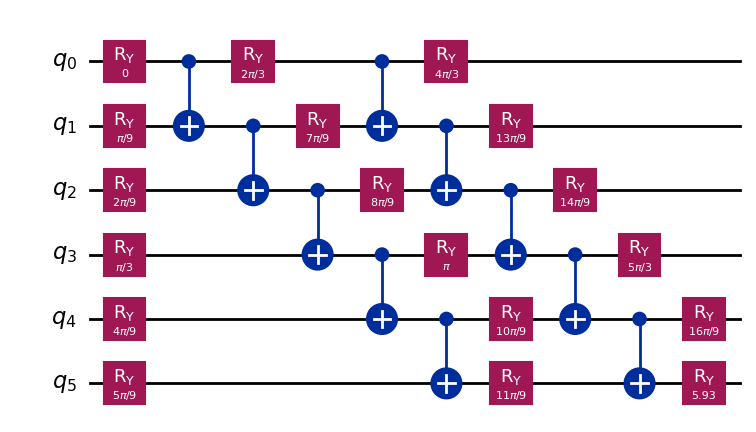

In [3]:
TEST_QUBITS = 6

def gen_theta(n):
    theta = np.zeros((n*NUM_THETA_LAYERS))
    for i in range(n*NUM_THETA_LAYERS):
        theta[i] = 2*np.pi*(i / (n*NUM_THETA_LAYERS))
    return theta

qc = circuit(TEST_QUBITS, gen_theta(TEST_QUBITS))
qc.draw("mpl")

## Simulated expectation value

Given that the circuit above produces $\ket{\psi} = U \ket{0}$, the goal is to compute $\bra{\psi} O \ket{\psi}$ where $O = Z_1 Z_2 \dots Z_n$ is the observable to measure. This test is based on frequently found ansatzë in QML circuits (this is just `RealAmplitudes`).